In [ ]:
!pip install transformers
!pip install albumentations
!pip install accelerate -U

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import random
import copy

# Transformers and SegFormer
from transformers import SegformerForSemanticSegmentation, SegformerConfig
from transformers import SegformerImageProcessor

# Data augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

Using device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
images_path = "/content/drive/MyDrive/ColabNotebooks/ML2/images"
masks_path = "/content/drive/MyDrive/ColabNotebooks/ML2/masks"

Dataset

In [ ]:
class FireDataset(Dataset):
    def __init__(self, images_path, masks_path, transform=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.transform = transform
        self.images = sorted(os.listdir(images_path))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_name = self.images[idx]
        img_path = os.path.join(self.images_path, img_name)
        mask_name = img_name.replace("_rgb", "_gt")
        mask_path = os.path.join(self.masks_path, mask_name)

        image = np.array(Image.open(img_path).convert("RGB"))
        mask = np.array(Image.open(mask_path).convert("L"))

        mask = (mask > 0).astype("float32")

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        if image.shape[1] != 256 or image.shape[2] != 256:
            image = torch.nn.functional.interpolate(
                image.unsqueeze(0), size=(256, 256), mode="bilinear", align_corners=False
            ).squeeze(0)

        if mask.shape[1] != 256 or mask.shape[2] != 256:
            mask = torch.nn.functional.interpolate(
                mask.unsqueeze(0), size=(256, 256), mode="nearest"
            ).squeeze(0)

        return image, mask

Data Augmentation

In [ ]:
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.Resize(256, 256),
    A.HueSaturationValue(p=0.3),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406),
                std=(0.229, 0.224, 0.225)),
    ToTensorV2()
])

Data Splits

In [ ]:
def create_data_splits(images_path, masks_path, train_transform, val_transform, data_percentage=1.0):
    """
    Create data splits with specific percentage of total dataset.

    Args:
        images_path: Path to images
        masks_path: Path to masks
        train_transform: Training transformations
        val_transform: Validation/test transformations
        data_percentage: Data split percentages (0.25, 0.5, 1.0)

    Returns:
        train_dataset, val_dataset, test_dataset
    """
    # Complete dataset
    total_size = len(FireDataset(images_path, masks_path))

    # Get size based on the percentage
    used_size = int(total_size * data_percentage)

    # Splits: 70% train, 15% val, 15% test
    train_size = int(0.7 * used_size)
    val_size = int(0.15 * used_size)
    test_size = used_size - train_size - val_size

    print(f"\nUsing {data_percentage*100:.0f}% of dataset:")
    print(f"  Total images: {total_size}")
    print(f"  Used images: {used_size}")
    print(f"  Train: {train_size}")
    print(f"  Val: {val_size}")
    print(f"  Test: {test_size}")

    # Create datasets
    full_train = FireDataset(images_path, masks_path, transform=train_transform)
    full_val = FireDataset(images_path, masks_path, transform=val_transform)
    full_test = FireDataset(images_path, masks_path, transform=val_transform)

    # Generar random indices
    indices = list(range(total_size))
    random.seed(42)
    random.shuffle(indices)

    # Take only the used percentage
    indices = indices[:used_size]

    # Divide in train/val/test
    train_indices = indices[:train_size]
    val_indices = indices[train_size:train_size + val_size]
    test_indices = indices[train_size + val_size:]

    # Create subsets
    train_dataset = Subset(full_train, train_indices)
    val_dataset = Subset(full_val, val_indices)
    test_dataset = Subset(full_test, test_indices)

    return train_dataset, val_dataset, test_dataset

Dice Loss (Loss function)

In [ ]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (
            preds.sum() + targets.sum() + self.smooth
        )

        return 1 - dice

Metrics

In [ ]:
def get_metrics(preds, targets, threshold=0.5):
    # Calculates F1, mIoU, MCC, HAF
    preds = torch.sigmoid(preds)
    preds = (preds > threshold).float()

    preds = preds.view(-1)
    targets = targets.view(-1)

    TP = (preds * targets).sum()
    TN = ((1 - preds) * (1 - targets)).sum()
    FP = (preds * (1 - targets)).sum()
    FN = ((1 - preds) * targets).sum()

    # F1 Score
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = (2 * precision * recall) / (precision + recall + 1e-8)

    # mIoU
    miou = TP / (TP + FP + FN + 1e-8)

    # MCC
    mcc = (TP * TN - FP * FN) / torch.sqrt(
        (TP + FP) * (TP + FN) * (TN + FP) * (TN + FN) + 1e-8
    )

    # HAF
    haf = TP / (TP + FP + FN + 1e-8)

    return f1.item(), miou.item(), mcc.item(), haf.item()

Epoch Training and Validation

In [ ]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    total_f1 = 0
    total_miou = 0
    total_mcc = 0
    total_haf = 0

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images)
        logits = outputs.logits

        if logits.shape[-2:] != masks.shape[-2:]:
            logits = nn.functional.interpolate(
                logits,
                size=masks.shape[-2:],
                mode='bilinear',
                align_corners=False
            )

        loss = criterion(logits, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        with torch.no_grad():
            f1, miou, mcc, haf = get_metrics(logits, masks)
            total_loss += loss.item()
            total_f1 += f1
            total_miou += miou
            total_mcc += mcc
            total_haf += haf

    n = len(loader)
    return total_loss/n, total_f1/n, total_miou/n, total_mcc/n, total_haf/n


def validate_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    total_f1 = 0
    total_miou = 0
    total_mcc = 0
    total_haf = 0

    with torch.no_grad():
        for images, masks in loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)
            logits = outputs.logits

            if logits.shape[-2:] != masks.shape[-2:]:
                logits = nn.functional.interpolate(
                    logits,
                    size=masks.shape[-2:],
                    mode='bilinear',
                    align_corners=False
                )

            loss = criterion(logits, masks)
            f1, miou, mcc, haf = get_metrics(logits, masks)

            total_loss += loss.item()
            total_f1 += f1
            total_miou += miou
            total_mcc += mcc
            total_haf += haf

    n = len(loader)
    return total_loss/n, total_f1/n, total_miou/n, total_mcc/n, total_haf/n

Early Stopping

In [ ]:
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4, verbose=True):
        """
        Args:
            patience  : epochs to wait without improvement before stopping
            min_delta : minimum change to count as an improvement
            verbose   : print a message each time the counter increases
        """
        self.patience   = patience
        self.min_delta  = min_delta
        self.verbose    = verbose
        self.counter    = 0
        self.best_loss  = None
        self.best_weights = None
        self.stop       = False

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            # Improvement found
            self.best_loss    = val_loss
            self.best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping: no improvement for {self.counter}/{self.patience} epochs "
                      f"(best val_loss={self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.stop = True

    def restore_best_weights(self, model):
        # Load the best weights back into the model.
        model.load_state_dict(self.best_weights)
        print(f"  Best weights restored (val_loss={self.best_loss:.4f})")


Training Model

In [ ]:
def train_model(train_loader, val_loader, test_loader, data_percentage, num_epochs=50):
    print(f"\n{'='*70}")
    print(f"TRAINING WITH {data_percentage*100:.0f}% OF DATASET")
    print(f"{'='*70}\n")

    # Create Model
    MODEL_NAME = "nvidia/segformer-b2-finetuned-ade-512-512"
    model = SegformerForSemanticSegmentation.from_pretrained(
        MODEL_NAME,
        num_labels=1,
        ignore_mismatched_sizes=True
    )
    model = model.to(device)

    # Loss y optimizer
    criterion = DiceLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

    # Early stopping (patience=10, monitors val_loss)
    early_stopping = EarlyStopping(patience=10, min_delta=1e-4, verbose=True)

    # Best-model tracking (based on mIoU)
    best_val_miou = 0.0
    best_model_path = f'best_segformer_{int(data_percentage*100)}percent.pth'

    # History
    history = {
        'train_loss': [], 'train_f1': [], 'train_miou': [], 'train_mcc': [], 'train_haf': [],
        'val_loss': [], 'val_f1': [], 'val_miou': [], 'val_mcc': [], 'val_haf': []
    }

    best_val_miou = 0.0
    best_model_path = f'best_segformer_{int(data_percentage*100)}percent.pth'

    # Training loop
    for epoch in range(num_epochs):
        # Train
        train_loss, train_f1, train_miou, train_mcc, train_haf = train_epoch(
            model, train_loader, criterion, optimizer, device
        )

        # Validate
        val_loss, val_f1, val_miou, val_mcc, val_haf = validate_epoch(
            model, val_loader, criterion, device
        )

        # Save history
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['train_miou'].append(train_miou)
        history['train_mcc'].append(train_mcc)
        history['train_haf'].append(train_haf)

        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)
        history['val_miou'].append(val_miou)
        history['val_mcc'].append(val_mcc)
        history['val_haf'].append(val_haf)

        # Print every 5 epochs
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}]")
            print(f"  Train - Loss: {train_loss:.4f}, F1: {train_f1:.4f}, mIoU: {train_miou:.4f}")
            print(f"  Val   - Loss: {val_loss:.4f}, F1: {val_f1:.4f}, mIoU: {val_miou:.4f}")

        # Save best model (based on mIoU)
        if val_miou > best_val_miou:
            best_val_miou = val_miou
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_miou': val_miou,
                'metrics': {'f1': val_f1, 'miou': val_miou, 'mcc': val_mcc, 'haf': val_haf}
            }, best_model_path)
            if (epoch + 1) % 5 == 0:
                print(f" Best model saved! (mIoU: {best_val_miou:.4f})")

    # Early stopping check
        early_stopping(val_loss, model)
        if early_stopping.stop:
            print(f"\n Early stopping triggered at epoch {epoch+1}")
            break

    # Restore best weights found during training
    early_stopping.restore_best_weights(model)
    print(f"\n✓ Best model also saved to '{best_model_path}' (mIoU={best_val_miou:.4f})")

    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"\nBest model loaded from epoch {checkpoint['epoch']+1}")

    # Final evaluation on test set
    test_loss, test_f1, test_miou, test_mcc, test_haf = validate_epoch(
        model, test_loader, criterion, device
    )

    print(f"\n{'='*70}")
    print(f"FINAL TEST RESULTS ({data_percentage*100:.0f}% dataset)")
    print(f"{'='*70}")
    print(f"Loss:  {test_loss:.4f}")
    print(f"F1:    {test_f1:.4f}")
    print(f"mIoU:  {test_miou:.4f}")
    print(f"MCC:   {test_mcc:.4f}")
    print(f"HAF:   {test_haf:.4f}")
    print(f"{'='*70}\n")

    return history, {
        'test_loss': test_loss,
        'test_f1': test_f1,
        'test_miou': test_miou,
        'test_mcc': test_mcc,
        'test_haf': test_haf
    }

Training with different percentages

In [ ]:
BATCH_SIZE = 8
NUM_EPOCHS = 50
PERCENTAGES = [0.25, 0.5, 1.0]  # 25%, 50%, 100%

# Store results
all_histories = {}
all_test_results = {}

print("Starting training with different dataset percentages...\n")

Starting training with different dataset percentages...



Training (25% dataset)

In [ ]:
train_25, val_25, test_25 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.25
)

train_loader_25 = DataLoader(train_25, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_25 = DataLoader(val_25, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_25 = DataLoader(test_25, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_25, test_results_25 = train_model(
    train_loader_25, val_loader_25, test_loader_25,
    data_percentage=0.25,
    num_epochs=NUM_EPOCHS
)

all_histories['25%'] = history_25
all_test_results['25%'] = test_results_25


Using 25% of dataset:
  Total images: 500
  Used images: 125
  Train: 87
  Val: 18
  Test: 20

TRAINING WITH 25% OF DATASET



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/110M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


model.safetensors:   0%|          | 0.00/110M [00:00<?, ?B/s]

Epoch [1/50]
  Train - Loss: 0.6350, F1: 0.5097, mIoU: 0.3526
  Val   - Loss: 0.5504, F1: 0.6859, mIoU: 0.5227
Epoch [5/50]
  Train - Loss: 0.3934, F1: 0.8038, mIoU: 0.6746
  Val   - Loss: 0.3810, F1: 0.7994, mIoU: 0.6660
 Best model saved! (mIoU: 0.6660)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.3785)
Epoch [10/50]
  Train - Loss: 0.2647, F1: 0.8854, mIoU: 0.7954
  Val   - Loss: 0.2542, F1: 0.8789, mIoU: 0.7842
 Best model saved! (mIoU: 0.7842)
Epoch [15/50]
  Train - Loss: 0.2050, F1: 0.8949, mIoU: 0.8128
  Val   - Loss: 0.1968, F1: 0.8764, mIoU: 0.7804
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.1919)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.1547)
Epoch [20/50]
  Train - Loss: 0.1308, F1: 0.9257, mIoU: 0.8623
  Val   - Loss: 0.1343, F1: 0.9165, mIoU: 0.8461
 Best model saved! (mIoU: 0.8461)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.1200)
  EarlyStopping: no improvement for 2/10 epochs (best va

Training (50% dataset)

In [ ]:
train_50, val_50, test_50 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=0.5
)

train_loader_50 = DataLoader(train_50, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_50 = DataLoader(val_50, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_50 = DataLoader(test_50, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_50, test_results_50 = train_model(
    train_loader_50, val_loader_50, test_loader_50,
    data_percentage=0.5,
    num_epochs=NUM_EPOCHS
)

all_histories['50%'] = history_50
all_test_results['50%'] = test_results_50


Using 50% of dataset:
  Total images: 500
  Used images: 250
  Train: 175
  Val: 37
  Test: 38

TRAINING WITH 50% OF DATASET



Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch [1/50]
  Train - Loss: 0.5988, F1: 0.6525, mIoU: 0.4929
  Val   - Loss: 0.4317, F1: 0.7434, mIoU: 0.5924
Epoch [5/50]
  Train - Loss: 0.2438, F1: 0.8851, mIoU: 0.7953
  Val   - Loss: 0.2003, F1: 0.9014, mIoU: 0.8211
 Best model saved! (mIoU: 0.8211)
Epoch [10/50]
  Train - Loss: 0.1272, F1: 0.9247, mIoU: 0.8602
  Val   - Loss: 0.1043, F1: 0.9326, mIoU: 0.8739
 Best model saved! (mIoU: 0.8739)
Epoch [15/50]
  Train - Loss: 0.0910, F1: 0.9381, mIoU: 0.8836
  Val   - Loss: 0.0774, F1: 0.9417, mIoU: 0.8900
 Best model saved! (mIoU: 0.8900)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0774)
Epoch [20/50]
  Train - Loss: 0.0777, F1: 0.9426, mIoU: 0.8916
  Val   - Loss: 0.0686, F1: 0.9437, mIoU: 0.8936
 Best model saved! (mIoU: 0.8936)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0686)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0658)
Epoch [25/50]
  Train - Loss: 0.0721, F1: 0.9427, mIoU: 0.8918
  Val   - Loss: 0.0671, F1: 0.

Training (100% dataset)

In [ ]:
train_100, val_100, test_100 = create_data_splits(
    images_path, masks_path, train_transform, val_transform, data_percentage=1.0
)

train_loader_100 = DataLoader(train_100, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader_100 = DataLoader(val_100, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader_100 = DataLoader(test_100, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

history_100, test_results_100 = train_model(
    train_loader_100, val_loader_100, test_loader_100,
    data_percentage=1.0,
    num_epochs=NUM_EPOCHS
)

all_histories['100%'] = history_100
all_test_results['100%'] = test_results_100


Using 100% of dataset:
  Total images: 500
  Used images: 500
  Train: 350
  Val: 75
  Test: 75

TRAINING WITH 100% OF DATASET



Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b2-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([1])                      
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([1, 768, 1, 1])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Epoch [1/50]
  Train - Loss: 0.5032, F1: 0.6869, mIoU: 0.5422
  Val   - Loss: 0.3231, F1: 0.8224, mIoU: 0.6988
Epoch [5/50]
  Train - Loss: 0.1472, F1: 0.9144, mIoU: 0.8429
  Val   - Loss: 0.1056, F1: 0.9299, mIoU: 0.8691
 Best model saved! (mIoU: 0.8691)
Epoch [10/50]
  Train - Loss: 0.0823, F1: 0.9379, mIoU: 0.8833
  Val   - Loss: 0.0704, F1: 0.9414, mIoU: 0.8893
 Best model saved! (mIoU: 0.8893)
  EarlyStopping: no improvement for 1/10 epochs (best val_loss=0.0621)
Epoch [15/50]
  Train - Loss: 0.0646, F1: 0.9457, mIoU: 0.8973
  Val   - Loss: 0.0764, F1: 0.9293, mIoU: 0.8682
  EarlyStopping: no improvement for 2/10 epochs (best val_loss=0.0621)
  EarlyStopping: no improvement for 3/10 epochs (best val_loss=0.0621)
  EarlyStopping: no improvement for 4/10 epochs (best val_loss=0.0621)
Epoch [20/50]
  Train - Loss: 0.0617, F1: 0.9452, mIoU: 0.8963
  Val   - Loss: 0.0582, F1: 0.9457, mIoU: 0.8971
 Best model saved! (mIoU: 0.8971)
  EarlyStopping: no improvement for 1/10 epochs (best va

Results

In [ ]:
print("\n" + "="*80)
print("SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES")
print("="*80)
print(f"{'Dataset':<12} {'Loss':<10} {'F1':<10} {'mIoU':<10} {'MCC':<10} {'HAF':<10}")
print("-"*80)

for pct in ['25%', '50%', '100%']:
    results = all_test_results[pct]
    print(f"{pct:<12} {results['test_loss']:<10.4f} {results['test_f1']:<10.4f} "
          f"{results['test_miou']:<10.4f} {results['test_mcc']:<10.4f} {results['test_haf']:<10.4f}")

print("="*80)


SUMMARY: TEST SET RESULTS FOR DIFFERENT DATASET SIZES
Dataset      Loss       F1         mIoU       MCC        HAF       
--------------------------------------------------------------------------------
25%          0.0908     0.9228     0.8576     0.9079     0.8576    
50%          0.0746     0.9333     0.8754     0.9178     0.8754    
100%         0.0551     0.9478     0.9009     0.9338     0.9009    


Learning Curves

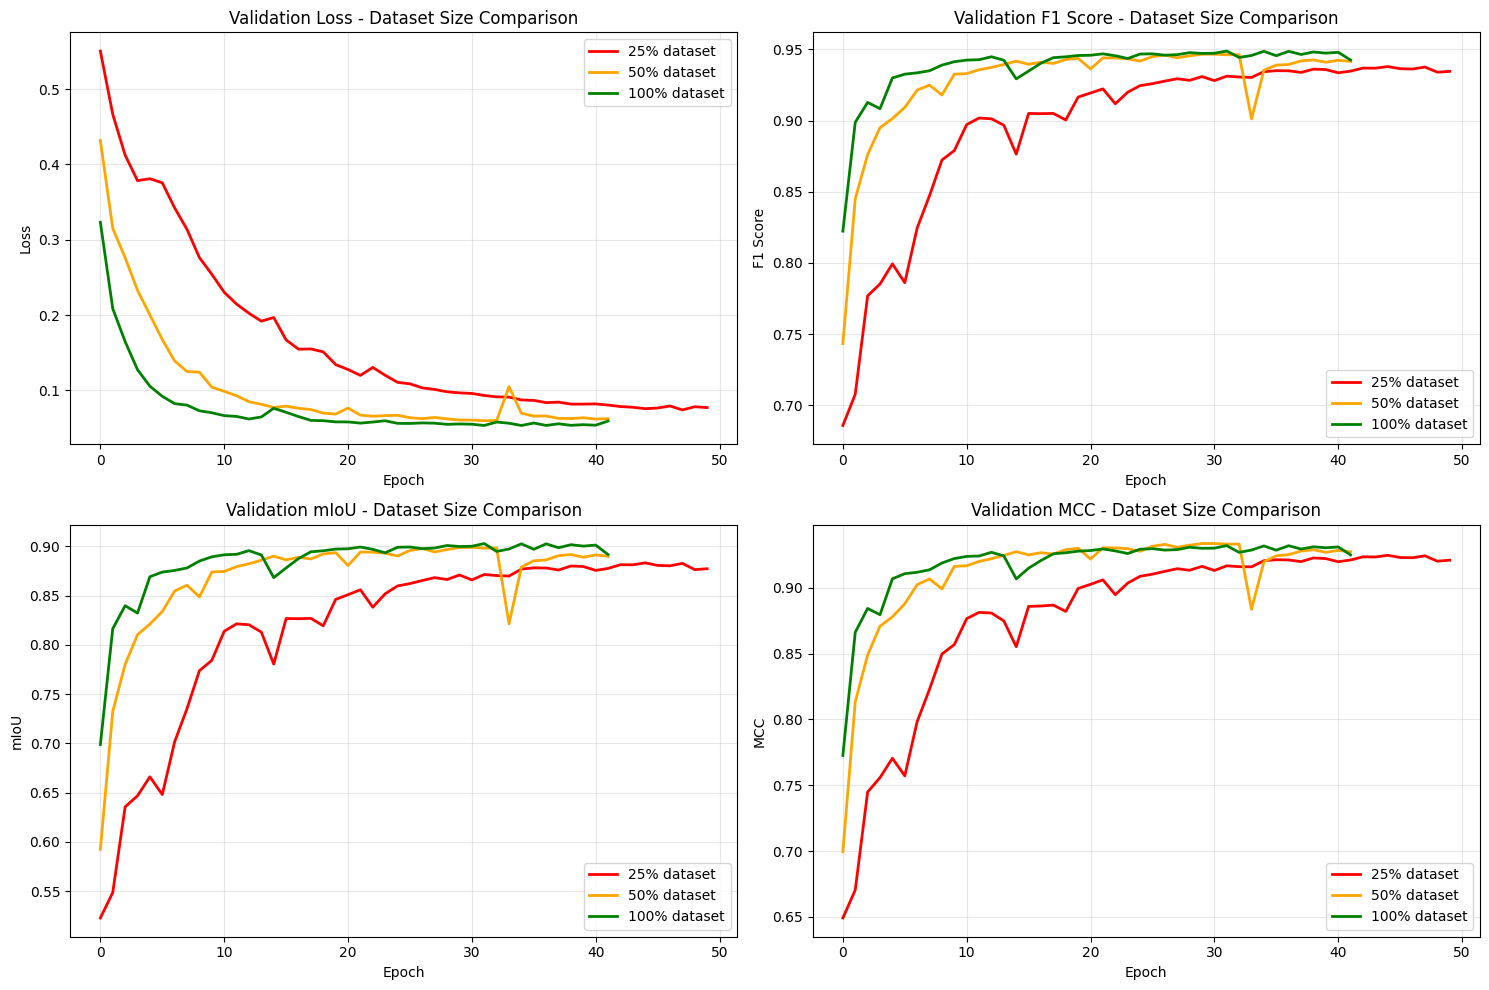

In [ ]:
# Comparar curvas de validación para diferentes porcentajes
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['loss', 'f1', 'miou', 'mcc']
titles = ['Loss', 'F1 Score', 'mIoU', 'MCC']
colors = {'25%': 'red', '50%': 'orange', '100%': 'green'}

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    row = idx // 2
    col = idx % 2

    for pct in ['25%', '50%', '100%']:
        history = all_histories[pct]
        axes[row, col].plot(
            history[f'val_{metric}'],
            label=f'{pct} dataset',
            color=colors[pct],
            linewidth=2
        )

    axes[row, col].set_xlabel('Epoch')
    axes[row, col].set_ylabel(title)
    axes[row, col].set_title(f'Validation {title} - Dataset Size Comparison')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('segformer_dataset_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import random

model_100.eval()

# Samplear índices aleatorios del test set (diferente cada vez)
num_imgs = 8
test_dataset = test_loader_100.dataset
random_indices = random.sample(range(len(test_dataset)), num_imgs)

# Construir batch manualmente
images_list, masks_list = [], []
for idx in random_indices:
    img, mask = test_dataset[idx]
    images_list.append(img)
    masks_list.append(mask)

images = torch.stack(images_list).to(device)
masks  = torch.stack(masks_list)

with torch.no_grad():
    outputs = model_100(images)
    preds = torch.sigmoid(outputs)
    preds = (preds > 0.5).float()

# Desnormalizar para visualizar
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(num_imgs, 3, figsize=(12, num_imgs * 4))

for i in range(num_imgs):
    img       = images[i].cpu() * std + mean
    img       = img.permute(1, 2, 0).clamp(0, 1)
    mask_real = masks[i].cpu().squeeze()
    mask_pred = preds[i].cpu().squeeze()

    axes[i, 0].imshow(img)
    axes[i, 0].set_title(f"Original image (idx {random_indices[i]})")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(mask_real, cmap="gray")
    axes[i, 1].set_title("Real mask")
    axes[i, 1].axis("off")

    axes[i, 2].imshow(mask_pred, cmap="gray")
    axes[i, 2].set_title("Predicted mask")
    axes[i, 2].axis("off")

plt.tight_layout()
plt.show()